In [2]:
"""
Corte de Intensidad (Intensity Slicing) para imágenes en escala de grises
AutorNatalia Rendón
Curso: Procesamiento de Imágenes

Descripción:
Esta técnica resalta un rango específico de intensidades en una imagen
en escala de grises, coloreando esos píxeles con un color definido por el usuario.
Útil para segmentación y análisis de imágenes médicas, satelitales, etc.
"""


'\nCorte de Intensidad (Intensity Slicing) para imágenes en escala de grises\nAutorNatalia Rendón\nCurso: Procesamiento de Imágenes\n\nDescripción:\nEsta técnica resalta un rango específico de intensidades en una imagen\nen escala de grises, coloreando esos píxeles con un color definido por el usuario.\nÚtil para segmentación y análisis de imágenes médicas, satelitales, etc.\n'

In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import os

In [9]:
def apply_intensity_slicing(image_path, intensity_range, color, return_mask=False):
    """
    Aplica corte de intensidad a una imagen en escala de grises.
    
    Parámetros:
    -----------
    image_path : str
        Ruta a la imagen en escala de grises
    intensity_range : tuple
        Tupla (min, max) con el rango de intensidad a resaltar (valores 0-255)
    color : tuple
        Tupla RGB con el color para resaltar el rango de intensidad
    return_mask : bool
        Si es True, retorna también la máscara binaria
        
    Retorna:
    --------
    colored_image : numpy.ndarray
        Imagen en color con el rango resaltado
    mask : numpy.ndarray 
    Máscara binaria de los píxeles dentro del rango
    """
    # Validar que el archivo existe
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"No se encontró la imagen en: {image_path}")
    
    # Cargar imagen en escala de grises
    gray_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if gray_image is None:
        raise ValueError(f"No se pudo leer la imagen: {image_path}")
    
    # Validar rango de intensidad
    min_int, max_int = intensity_range
    if min_int < 0 or max_int > 255 or min_int > max_int:
        raise ValueError(f"Rango inválido: ({min_int}, {max_int}). Debe estar entre 0 y 255")
    
    # Crear versión en color de la imagen (tres canales iguales = escala de grises)
    colored_image = cv2.cvtColor(gray_image, cv2.COLOR_GRAY2RGB)
    
    # Crear máscara que identifique los píxeles dentro del rango de intensidad
    mask = cv2.inRange(gray_image, intensity_range[0], intensity_range[1])
    
    # Aplicar el color especificado a los píxeles dentro del rango
    colored_image[mask != 0] = color
    
    if return_mask:
        return colored_image, mask
    
    return colored_image

def apply_multiple_slicing(image_path, ranges_colors):
    """
    Aplica múltiples cortes de intensidad con diferentes colores
    
    Parámetros:
    -----------
    image_path : str
        Ruta a la imagen en escala de grises
    ranges_colors : list
        Lista de tuplas [(rango1, color1), (rango2, color2), ...]
    
    Retorna:
    --------
    colored_image : numpy.ndarray
        Imagen en color con múltiples rangos resaltados
    """
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"No se encontró la imagen en: {image_path}")
    
    gray_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if gray_image is None:
        raise ValueError(f"No se pudo leer la imagen: {image_path}")
    
    colored_image = cv2.cvtColor(gray_image, cv2.COLOR_GRAY2RGB)
    
    for intensity_range, color in ranges_colors:
        mask = cv2.inRange(gray_image, intensity_range[0], intensity_range[1])
        colored_image[mask != 0] = color
    
    return colored_image

def cargar_imagen_rgb(ruta_imagen):
    """Carga una imagen y la convierte de BGR a RGB"""
    if not os.path.exists(ruta_imagen):
        raise FileNotFoundError(f"No se encontró la imagen en: {ruta_imagen}")
    
    img = cv2.imread(ruta_imagen)
    
    if img is None:
        raise ValueError(f"No se pudo leer la imagen: {ruta_imagen}")
    
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def visualizar_comparacion_tres(imagen_rgb, imagen_gris, imagen_coloreada):
    """
    Muestra tres imágenes lado a lado para comparación
    """
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(imagen_rgb)
    plt.title('Imagen RGB Original')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(imagen_gris, cmap='gray')
    plt.title('Imagen en Escala de Grises')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(imagen_coloreada)
    plt.title('Corte de Intensidad')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def visualizar_con_mascara(imagen_gris, mascara, imagen_coloreada):
    """
    Muestra la imagen original, la máscara y el resultado
    """
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(imagen_gris, cmap='gray')
    plt.title('Imagen en Escala de Grises')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(mascara, cmap='gray')
    plt.title('Máscara del Rango')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(imagen_coloreada)
    plt.title('Resultado Coloreado')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()



Aplicando corte de intensidad a un rango


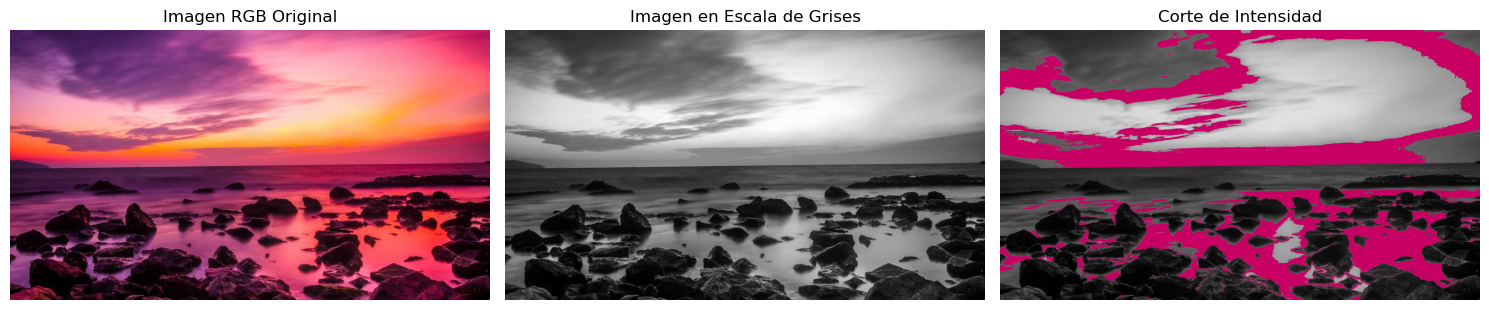

Mostrando máscara del rango


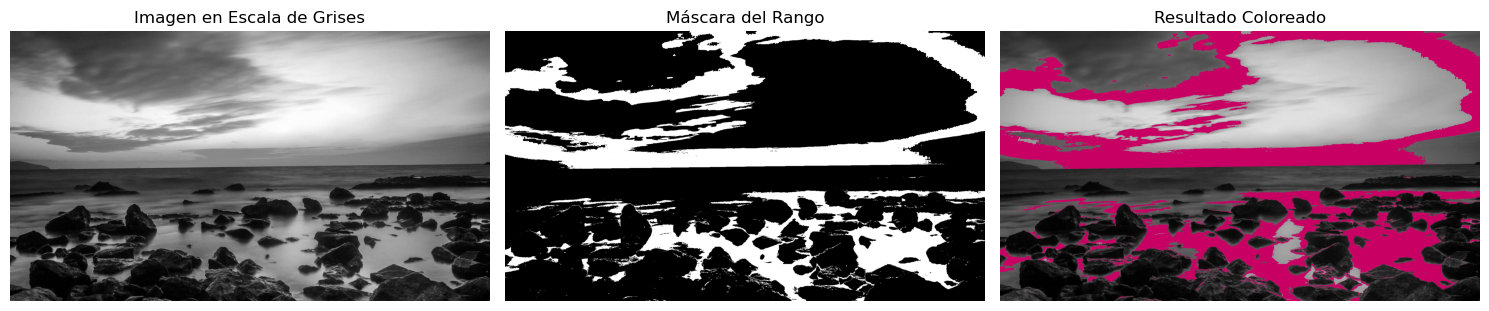

Aplicando múltiples cortes de intensidad


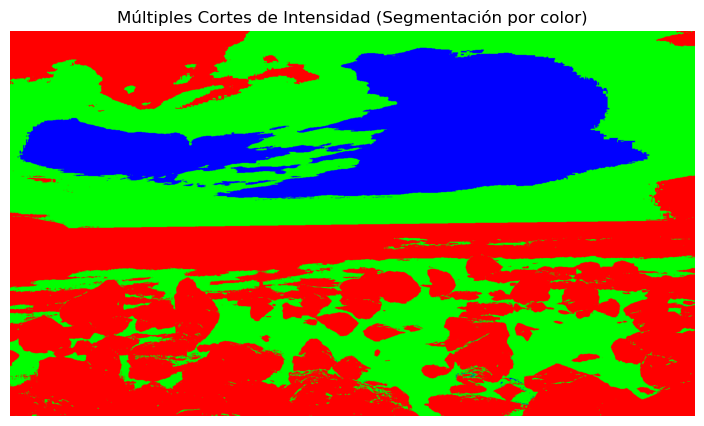


Tip: Modifica intensity_range y color para resaltar diferentes áreas


In [10]:
# ============ EJECUCIÓN PRINCIPAL ============
if __name__ == "__main__":
    try:
        # Configuración
        ruta_imagen = "sunset.jpg"  # Cambia por tu imagen
        
        # Cargar imagen RGB original para comparación
        imagen_rgb = cargar_imagen_rgb(ruta_imagen)
        
        # Cargar imagen en grises
        imagen_gris = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)
        
        # EJEMPLO 1: Un solo rango
        print("Aplicando corte de intensidad a un rango")
        intensity_range = (100, 150)  # Rango de intensidades a resaltar
        color = (200, 0, 100)         # Color magenta
        
        imagen_coloreada = apply_intensity_slicing(ruta_imagen, intensity_range, color)
        
        # Visualizar comparación
        visualizar_comparacion_tres(imagen_rgb, imagen_gris, imagen_coloreada)
        
        # EJEMPLO 2: Con máscara
        print("Mostrando máscara del rango")
        imagen_coloreada, mascara = apply_intensity_slicing(
            ruta_imagen, intensity_range, color, return_mask=True
        )
        visualizar_con_mascara(imagen_gris, mascara, imagen_coloreada)
        
        # EJEMPLO 3: Múltiples rangos
        print("Aplicando múltiples cortes de intensidad")
        ranges_colors = [
            ((0, 85), (255, 0, 0)),      # Rango bajo → Rojo
            ((85, 170), (0, 255, 0)),    # Rango medio → Verde
            ((170, 255), (0, 0, 255))    # Rango alto → Azul
        ]
        
        imagen_multiple = apply_multiple_slicing(ruta_imagen, ranges_colors)
        
        plt.figure(figsize=(12, 5))
        plt.imshow(imagen_multiple)
        plt.title('Múltiples Cortes de Intensidad (Segmentación por color)')
        plt.axis('off')
        plt.show()

    
        print("\nTip: Modifica intensity_range y color para resaltar diferentes áreas")
        
    except Exception as e:
        print(f"Error: {e}")
        print("\nSugerencias:")
        print("- Verifica que la imagen exista en la ruta especificada")
        print("- Para imágenes a color, se convierten automáticamente a grises")
        print("- El rango de intensidad debe estar entre 0 y 255")